In [1]:
# Domain Adaptation Model Testing Notebook
# Load and test trained DA models with comprehensive evaluation

import sys
sys.path.append("..")

import torch
import torch.nn.functional as F
import numpy as np
import yaml
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve

from src.models.base_models import create_model
from src.models.domain_discriminator import DomainDiscriminator, create_da_model
from src.data.numu_dataset import NuMuDataset, create_numu_dataloader_from_ds

# Set up paths and experiment
EXPERIMENT_DIR = Path("../experiments/numu/da_numu_251015_middle_progress_lambda_aug")
DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")

print(f"Testing experiment: {EXPERIMENT_DIR.name}")
print(f"Device: {DEVICE}")

Testing experiment: da_numu_251015_middle_progress_lambda_aug
Device: cuda:1


In [2]:
# Load configuration files
config_path = EXPERIMENT_DIR / "da_config.yaml"
norm_config_path = EXPERIMENT_DIR / "normalization_config.yaml"

with open(config_path, 'r') as f:
    config = yaml.safe_load(f)

with open(norm_config_path, 'r') as f:
    normalization_config = yaml.safe_load(f)

print("Configuration loaded:")
print(f"- Model type: {config['model']['type']}")
print(f"- Feature extractor d_model: {config['model']['feature_extractor']['d_model']}")
print(f"- Seed: {config['experiment']['seed']}")
print(f"- Max hits: {config['data']['max_hits']}")

Configuration loaded:
- Model type: numu
- Feature extractor d_model: 128
- Seed: 42
- Max hits: 500


In [3]:
# Load trained models from best checkpoint
checkpoint_path = EXPERIMENT_DIR / "best_da_model.pth"
print(f"Loading checkpoint from: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location=DEVICE)

# Create and load base model
model = create_model(config['model'])
model.load_state_dict(checkpoint['base_model_state_dict'])
model.to(DEVICE)
model.eval()

# Create and load domain discriminator
feature_dim = config['model']['feature_extractor']['d_model']
domain_discriminator = DomainDiscriminator(
    input_dim=feature_dim,
    **config['domain_adaptation']['domain_discriminator']
)
domain_discriminator.load_state_dict(checkpoint['domain_discriminator_state_dict'])
domain_discriminator.to(DEVICE)
domain_discriminator.eval()

print("Models loaded successfully:")
print(f"- Epoch: {checkpoint.get('epoch', 'unknown')}")
print(f"- Best metric: {checkpoint.get('best_metric', 'unknown')}")
print(f"- Base model parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"- Domain discriminator parameters: {sum(p.numel() for p in domain_discriminator.parameters()):,}")

Loading checkpoint from: ../experiments/numu/da_numu_251015_middle_progress_lambda_aug/best_da_model.pth


/tmp/ipykernel_29518/459895799.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(checkpoint_path, map_location=DEVICE)


Models loaded successfully:
- Epoch: 23
- Best metric: 0.9728524442700103
- Base model parameters: 541,633
- Domain discriminator parameters: 10,561


In [4]:
# Create test dataset (using source domain for classification evaluation)
source_config = config['data']['source_domain']
train_events_per_particle = config['data']['source_domain']['events_per_particle']

# Use validation portion of source data for testing (events model hasn't seen)
test_dataset = NuMuDataset(
    h5_path=source_config['h5_path'],
    events_per_particle={'muatm_2020': 50000, 'nue2_2020': 25000, 'nuatm_2020': 25000},  # Test portion
    particle_types=source_config['particle_types'],
    neutrino_types=source_config['neutrino_types'],
    max_hits=config['data']['max_hits'],
    sampling_config={
        'muatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['muatm_2020']},
        'nue2_2020': {'mode': 'range', 'start_event': train_events_per_particle['nue2_2020']},
        'nuatm_2020': {'mode': 'range', 'start_event': train_events_per_particle['nuatm_2020']}
        },
    device='cuda:1',
    shuffle_events=False
)
source_magic_numbers = test_dataset.magic_numbers  # For reference
print(f"Test dataset created with {len(test_dataset)} events")
print(f"Particle distribution:")
for particle in source_config['particle_types']:
    count = sum(1 for i in range(len(test_dataset)) if test_dataset.event_ids[i].split(":")[0] == particle)
    print(f"  {particle}: {count:,} events")

Test dataset created with 100000 events
Particle distribution:
  muatm_2020: 50,000 events
  nue2_2020: 25,000 events
  nuatm_2020: 25,000 events


In [5]:
# Create test dataloader
test_dataloader = create_numu_dataloader_from_ds(
    dataset=test_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    augmentation_config=None,  # No augmentation for testing
    num_workers=0,
    shuffle=False,
    shuffle_batch=False
)

print(f"Test dataloader created:")
print(f"- Batch size: 256")
print(f"- Number of batches: {len(test_dataloader)}")
print(f"- Total events: {len(test_dataset)}")
print(f"- Normalization: {normalization_config['feature_names']}")
print(f"- Means: {normalization_config['means']}")
print(f"- Stds: {normalization_config['stds']}")

Test dataloader created:
- Batch size: 256
- Number of batches: 391
- Total events: 100000
- Normalization: ['amplitude', 'time', 'x', 'y', 'z']
- Means: [2.0, 0.0, 0.0, 0.0, 0.0]
- Stds: [60.0, 1370.0, 40.0, 40.0, 150.0]


In [6]:
test_dataloader.batch_size

256

In [64]:
# Make predictions on test data
print("Making predictions...")

all_predictions = []
all_probabilities = []
all_labels = []
all_features = []

with torch.no_grad():
    for i, batch in enumerate(test_dataloader):
        if i % 100 == 0:
            print(f"Processing batch {i+1}/{len(test_dataloader)}")
        
        # Get feature representations and predictions
        feature_repr = model.get_feature_representation(batch)
        logits = model.classifier(feature_repr)
        probabilities = torch.sigmoid(logits)
        predictions = (probabilities > 0.5).float()
        
        # Store results
        all_features.append(feature_repr.cpu())
        all_predictions.append(predictions.cpu())
        all_probabilities.append(probabilities.cpu())
        all_labels.append(batch['labels'].cpu())

# Concatenate all results
features = torch.cat(all_features, dim=0).numpy()
predictions = torch.cat(all_predictions, dim=0).numpy().flatten()
probabilities = torch.cat(all_probabilities, dim=0).numpy().flatten()
labels = torch.cat(all_labels, dim=0).numpy().flatten()

print(f"Predictions complete:")
print(f"- Features shape: {features.shape}")
print(f"- Predictions shape: {predictions.shape}")
print(f"- Labels shape: {labels.shape}")
print(f"- Neutrino prediction rate: {np.mean(predictions):.3f}")
print(f"- True neutrino rate: {np.mean(labels):.3f}")

Making predictions...
Processing batch 1/391
Processing batch 101/391
Processing batch 201/391
Processing batch 301/391
Predictions complete:
- Features shape: (100000, 128)
- Predictions shape: (100000,)
- Labels shape: (100000,)
- Neutrino prediction rate: 0.537
- True neutrino rate: 0.500


In [65]:
# Calculate comprehensive metrics
print("=== Classification Metrics ===")

signal_hit_nums = np.asarray([(numbers!=0).sum() for numbers in source_magic_numbers])
mask = (signal_hit_nums>=8)
labels2, probabilities2, predictions2 = labels[mask], probabilities[mask], predictions[mask]

# Basic metrics
accuracy = accuracy_score(labels2, predictions2)
precision = precision_score(labels2, predictions2, average='binary')
recall = recall_score(labels2, predictions2, average='binary')
f1 = f1_score(labels2, predictions2, average='binary')
auc = roc_auc_score(labels2, probabilities2)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"AUC:       {auc:.4f}")

# Per-class metrics
precision_muon = precision_score(labels2, predictions2, pos_label=0)
precision_neutrino = precision_score(labels2, predictions2, pos_label=1)
recall_muon = recall_score(labels2, predictions2, pos_label=0)
recall_neutrino = recall_score(labels2, predictions2, pos_label=1)

print(f"\nPer-class metrics:")
print(f"Muon     - Precision: {precision_muon:.4f}, Recall: {recall_muon:.4f}")
print(f"Neutrino - Precision: {precision_neutrino:.4f}, Recall: {recall_neutrino:.4f}")

# Confusion matrix
cm = confusion_matrix(labels2, predictions2)
print(f"\nConfusion Matrix:")
print(f"                 Predicted")
print(f"                Muon  Neutrino")
print(f"Actual Muon     {cm[0,0]:5d}  {cm[0,1]:5d}")
print(f"    Neutrino    {cm[1,0]:5d}  {cm[1,1]:5d}")

# Class distribution
total_muons = np.sum(labels2 == 0)
total_neutrinos = np.sum(labels2 == 1)
print(f"\nClass distribution:")
print(f"Total muons: {total_muons:,}")
print(f"Total neutrinos: {total_neutrinos:,}")
print(f"Balance: {total_neutrinos/(total_muons+total_neutrinos):.3f}")

=== Classification Metrics ===
Accuracy:  0.9753
Precision: 0.9658
Recall:    0.9914
F1 Score:  0.9784
AUC:       0.9981

Per-class metrics:
Muon     - Precision: 0.9883, Recall: 0.9543
Neutrino - Precision: 0.9658, Recall: 0.9914

Confusion Matrix:
                 Predicted
                Muon  Neutrino
Actual Muon     11001    527
    Neutrino      130  14904

Class distribution:
Total muons: 11,528
Total neutrinos: 15,034
Balance: 0.566


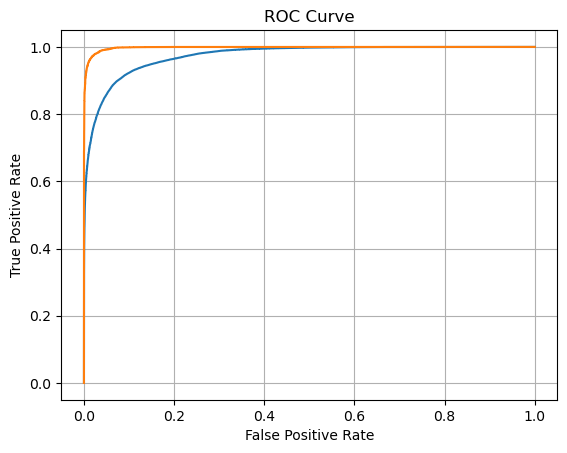

In [ ]:
fpr, tpr, thresholds = roc_curve(labels, probabilities)
plt.plot(fpr, tpr)

fpr, tpr, thresholds = roc_curve(labels2, probabilities2)
plt.plot(fpr, tpr)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid()
plt.show()

In [67]:
fpr[tpr>=0.99]

array([0.04068355, 0.04094379, 0.04094379, 0.04120402, 0.04120402,
       0.0417245 , 0.0417245 , 0.0426787 , 0.0426787 , 0.04285219,
       0.04285219, 0.04302568, 0.04302568, 0.04328591, 0.04328591,
       0.0434594 , 0.0434594 , 0.04363289, 0.04363289, 0.04406662,
       0.04406662, 0.04476058, 0.04476058, 0.04493407, 0.04493407,
       0.04545455, 0.04545455, 0.04554129, 0.04554129, 0.04580153,
       0.04580153, 0.04588827, 0.04588827, 0.04597502, 0.04597502,
       0.04640874, 0.04640874, 0.04666898, 0.04666898, 0.04675573,
       0.04675573, 0.04701596, 0.04701596, 0.04736294, 0.04736294,
       0.04797016, 0.04797016, 0.04840389, 0.04840389, 0.04892436,
       0.04892436, 0.04944483, 0.04944483, 0.05022554, 0.05022554,
       0.05031228, 0.05031228, 0.05143997, 0.05143997, 0.05178695,
       0.05178695, 0.0528279 , 0.0528279 , 0.05343511, 0.05343511,
       0.05352186, 0.05352186, 0.05404233, 0.05404233, 0.05473629,
       0.05473629, 0.05517002, 0.05517002, 0.05569049, 0.05569

In [68]:
# Optional: Test domain discrimination (if you have target domain data)
print("=== Domain Discrimination Test ===")

# Create a small sample of target domain data for domain discrimination test
target_config = config['data']['target_domain']
target_dataset = NuMuDataset(
    h5_path=target_config['h5_path'],
    particle_types=target_config['particle_types'],
    neutrino_types=target_config.get('neutrino_types', []),
    sampling_config={
        'exp': {
            'mode': 'range', 'start_event': 600_000# target_config['events_per_particle']['exp']
                }},
    events_per_particle={'exp': 100_000},  # Small sample
    max_hits=config['data']['max_hits'],
    device='cuda:1',
    shuffle_events=False
)

target_dataloader = create_numu_dataloader_from_ds(
    dataset=target_dataset,
    batch_size=256,
    normalization_config=normalization_config,
    shuffle_batch=False,
    augmentation_config=None,
    num_workers=0,
    shuffle=False
)

# Extract features from both domains
source_features = []
target_features = []

# Source features (limited sample)
with torch.no_grad():
    for i, batch in enumerate(test_dataloader):
        # if i >= 10:  # Limit to 10 batches for comparison
        #     break
        feature_repr = model.get_feature_representation(batch)
        source_features.append(feature_repr.cpu())

# Target features
with torch.no_grad():
    for i, batch in enumerate(target_dataloader):
        # if i >= 10:  # Limit to 10 batches for comparison
        #     break
        feature_repr = model.get_feature_representation(batch)
        target_features.append(feature_repr.cpu())

# Combine and test domain discrimination
source_features = torch.cat(source_features, dim=0)
target_features = torch.cat(target_features, dim=0)

all_domain_features = torch.cat([source_features, target_features], dim=0).to(DEVICE)
domain_labels = torch.cat([
    torch.zeros(source_features.shape[0]),  # 0 = source
    torch.ones(target_features.shape[0])    # 1 = target
], dim=0)

# Get domain predictions
with torch.no_grad():
    domain_logits = domain_discriminator(all_domain_features)
    domain_probs = torch.sigmoid(domain_logits).cpu().numpy().flatten()
    domain_preds = (domain_probs > 0.5).astype(float)

domain_accuracy = accuracy_score(domain_labels.numpy(), domain_preds)
domain_auc = roc_auc_score(domain_labels.numpy(), domain_probs)

print(f"Domain discrimination accuracy: {domain_accuracy:.4f}")
print(f"Domain discrimination AUC: {domain_auc:.4f}")
print(f"Note: Lower accuracy indicates better domain adaptation")
print(f"Source samples: {source_features.shape[0]:,}")
print(f"Target samples: {target_features.shape[0]:,}")

=== Domain Discrimination Test ===
Domain discrimination accuracy: 0.4305
Domain discrimination AUC: 0.4154
Note: Lower accuracy indicates better domain adaptation
Source samples: 100,000
Target samples: 49,976


In [69]:
signal_hit_nums = np.asarray([(numbers!=0).sum() for numbers in source_magic_numbers])
mask = np.concatenate(
    ((signal_hit_nums>=8), np.ones(target_features.size(0), dtype=bool))
)
domain_labels2, domain_probs2, domain_preds2 = domain_labels[mask], domain_probs[mask], domain_preds[mask]

In [70]:
confusion_matrix((1-domain_labels2).numpy(), domain_preds2)

array([[13013, 36963],
       [ 3252, 23310]])

In [71]:
domain_labels2

tensor([0., 0., 0.,  ..., 1., 1., 1.])

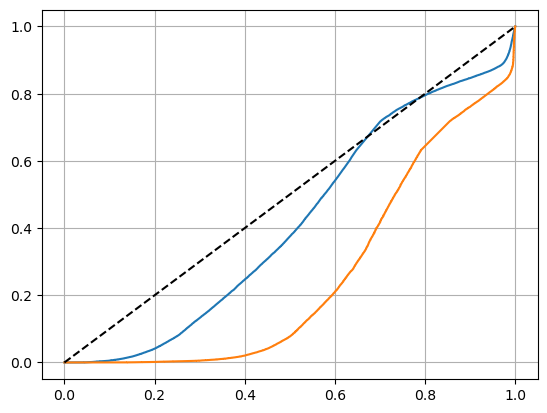

In [72]:
fpr, tpr, tresholds = roc_curve(domain_labels, domain_probs)
plt.plot(fpr, tpr)

fpr, tpr, tresholds = roc_curve(domain_labels2, domain_probs2)
plt.plot(fpr, tpr)

x = np.linspace(0,1,100)
plt.plot(x,x, '--', color='black')

plt.grid()

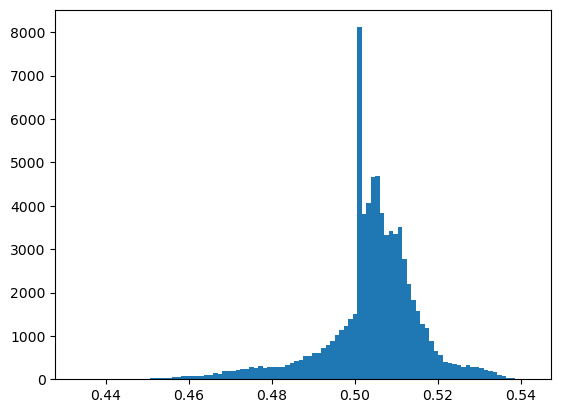

In [73]:
plt.hist(domain_probs2, bins=100)
plt.show()

In [74]:
# Save results (optional)
results_dict = {
    'experiment': EXPERIMENT_DIR.name,
    'accuracy': float(accuracy),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'auc': float(auc),
    'precision_muon': float(precision_muon),
    'precision_neutrino': float(precision_neutrino),
    'recall_muon': float(recall_muon),
    'recall_neutrino': float(recall_neutrino),
    'confusion_matrix': cm.tolist(),
    'total_muons': int(total_muons),
    'total_neutrinos': int(total_neutrinos),
    'test_events': len(predictions)
}

# Create results DataFrame for easy viewing
results_df = pd.DataFrame([results_dict])
print("=== Results Summary ===")
print(results_df[['accuracy', 'precision', 'recall', 'f1_score', 'auc']].round(4))

# Save to file
results_path = EXPERIMENT_DIR / "test_results.yaml"
with open(results_path, 'w') as f:
    yaml.dump(results_dict, f, default_flow_style=False, indent=2)

print(f"\nResults saved to: {results_path}")
print(f"Test completed successfully!")

=== Results Summary ===
   accuracy  precision  recall  f1_score     auc
0    0.9753     0.9658  0.9914    0.9784  0.9981

Results saved to: ../experiments/numu/da_numu_251015_middle_progress_lambda_aug/test_results.yaml
Test completed successfully!
